<a href="https://colab.research.google.com/github/vahagngrigoryan2006/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vahagngrigoryan2006/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Lane 1 — Ranking Signal Analysis.** Which safe content and search signals are associated with a
page losing visibility, and how large is each association?

**The decision.** An editor covering a multi-client content portfolio can open roughly **50 pages a
week**. The scarce resource is attention, not analysis. So the operational question is not *which
pages are declining* but **which pages to open first** — an ordering problem with a fixed budget.

**Unit of analysis.** One content item at one monthly decision point. (With a single decision date
per frame this collapses to one row per page; a second decision date would produce a second row for
the same page, so the true grain is content × decision date.)

**Output.** A ranked review queue, with a human-readable reason code on every row.

**Action.** An editor opens the top rows and judges them. Nothing is edited, unpublished, or
reprioritised automatically.

**Cost of a wrong call.** A false positive spends editor hours on a healthy page; a false negative
lets a page decay unnoticed. Both are recoverable — which is exactly why this is decision support
rather than automation.

In [24]:
import json, os, sys

# Run from the repo root whether launched in Colab or locally.
if "google.colab" in sys.modules and not os.path.isdir("work"):
    import subprocess
    if not os.path.isdir("flyrank-internship-ml"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/vahagngrigoryan2006/flyrank-internship-ml.git"], check=True)
    os.chdir("flyrank-internship-ml")
else:
    while not os.path.isdir("work") and os.getcwd() != "/":
        os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# The committed receipts every number in the paper traces back to.
METRICS = json.load(open("work/outputs/w07_playbook_metrics.json"))

train = METRICS["training_frame"]
june = METRICS["sealed_june_frame"]
print(f"Warehouse build:      {METRICS['warehouse_build']}")
print(f"Training frame:       {train['n_rows']:,} rows, {train['n_clients']} clients, "
      f"base rate {train['base_rate']:.3f}  (decision moment {train['decision_moment']})")
print(f"Sealed June frame:    {june['n_rows']:,} rows, {june['n_clients']} clients, "
      f"base rate {june['base_rate']:.3f}  (decision moment {june['decision_moment']}, read {june['read']})")
print(f"\nReview budget assumed throughout: {METRICS['queue']['review_budget']} pages/week")

Warehouse build:      flyrank_pseudonymized_warehouse_release_v20260703
Training frame:       18,918 rows, 27 clients, base rate 0.543  (decision moment 2026-05-01)
Sealed June frame:    55,904 rows, 42 clients, base rate 0.671  (decision moment 2026-06-01, read once)

Review budget assumed throughout: 50 pages/week


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release.** FlyRank internship warehouse, build `v20260703` — a pseudonymized export derived from
Google Search Console and Google Analytics 4 data aggregated in BigQuery.

**Tables used.** `fact_content_daily_performance` (78,835,655 rows; grain `report_date × client ×
content`) and `dim_content` (519,606 rows; one row per content item). The query table and
`dim_clients` were not used.

**Panel span.** 2025-01-27 → 2026-06-30. Two frames were built with identical logic, parameterised
only by the as-of date, so the walk-forward compares like with like.

**Three population guards** (none consults the outcome window): at least 60 days of prior history;
at least 100 impressions in the feature window; a last-update date strictly before the decision
moment.

**Deliberate exclusions.** Pseudonymous IDs (grouping and splitting only, never features); pipeline
metadata `provider_used` / `model_used` (describes how a page was produced, not how search behaved);
product flags `is_published` / `is_deleted` (outputs of decisions, not inputs); and the label's own
ingredients, which are quarantined and tested for in §3.

**Public-safety.** No client names, domains, URLs, or raw queries appear anywhere in this notebook,
the paper, or the repository. The row-level queue CSV is regenerated per run and gitignored.

In [25]:
frames = pd.DataFrame([
    {"frame": "training", "feature_window": "April 2026", "outcome_window": "May 2026",
     "decision_moment": train["decision_moment"], "rows": train["n_rows"],
     "clients": train["n_clients"], "base_rate": round(train["base_rate"], 3)},
    {"frame": "sealed walk-forward", "feature_window": "May 2026", "outcome_window": "June 2026",
     "decision_moment": june["decision_moment"], "rows": june["n_rows"],
     "clients": june["n_clients"], "base_rate": round(june["base_rate"], 3)},
])
print("Analysis frames (from the committed metrics receipts):")
print(frames.to_string(index=False))

print("\nPopulation funnel on the sealed June frame:")
q = METRICS["queue"]
funnel = pd.DataFrame({
    "stage": ["rows in frame", "pass all 3 rule eligibility gates", "rule fires (rank-ordered)",
               "shipped in the weekly review batch"],
    "n": [june["n_rows"], q["n_eligible"], q["n_rule_flagged"], q["review_budget"]],
})
funnel["share_of_frame"] = (funnel["n"] / june["n_rows"]).round(4)
print(funnel.to_string(index=False))

print("\nNOTE the population asymmetry -- a stated limitation, not a bug:")
print(f"  the sealed frame holds {june['n_rows']:,} rows / {june['n_clients']} clients against the "
      f"training frame's {train['n_rows']:,} / {train['n_clients']}.")
print("  A fixed 60-day history guard admits more items as the panel deepens, so the walk-forward")
print("  scores a broader population than the models were fitted on.")

Analysis frames (from the committed metrics receipts):
              frame feature_window outcome_window decision_moment  rows  clients  base_rate
           training     April 2026       May 2026      2026-05-01 18918       27      0.543
sealed walk-forward       May 2026      June 2026      2026-06-01 55904       42      0.671

Population funnel on the sealed June frame:
                             stage     n  share_of_frame
                     rows in frame 55904          1.0000
 pass all 3 rule eligibility gates  7298          0.1305
         rule fires (rank-ordered)  1549          0.0277
shipped in the weekly review batch    50          0.0009

NOTE the population asymmetry -- a stated limitation, not a bug:
  the sealed frame holds 55,904 rows / 42 clients against the training frame's 18,918 / 27.
  A fixed 60-day history guard admits more items as the panel deepens, so the walk-forward
  scores a broader population than the models were fitted on.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label — an observed outcome, not a rule output.** A page is labelled declining when impressions in
the 30-day window *after* the decision moment fall more than 20% below the 30-day window before it.
An earlier iteration used the starter dataset's `trend_direction`, which is computed from the
*current* window and describes a snapshot rather than a future outcome; it was abandoned for the
forward-looking definition. That distinction is the difference between scoring what already happened
and predicting what happens next.

**Features — 23 predictors, all observable at the decision moment.** Seven feature-window search and
analytics aggregates, static content and keyword attributes from `dim_content`, three age measures
computed to the decision moment, and two explicit missingness flags. The flags exist because roughly
a quarter of items lack keyword data; a blind zero-fill would smuggle a category signal into the
feature set.

**Baseline — a frozen, transparent rule.** `CTR_BELOW_POSITION_PEERS` fires when a page clears three
eligibility gates (≥500 impressions, ≥90 days old, not optimised in the last 60 days) and records
*zero* clicks. Flagged rows score `impressions × (peer-tier expected CTR − own CTR)`. The peer
benchmark is learned **from training rows only** in every fold — the rule is held to the same
train/test discipline as the models.

**Models.** Logistic regression (scaled numeric + one-hot categorical) and a decision tree capped at
`max_depth=3, min_samples_leaf=200` so its full reasoning fits in eight readable paths. Both use
`random_state=42`.

**Validation.** `GroupKFold(n_splits=10)` on `client_hash_id` — no client appears on both sides.
Fold base rates range 0.255–0.931, so the split design dominates the result. 95% confidence
intervals come from a paired bootstrap of 10,000 resamples over fold results; F1 intervals are
derived from each resample's own precision and recall rather than bootstrapped separately.

**Leakage checks (three, all in `w06_validation_audit.ipynb`).** A feature timeline confirming all
23 predictors are knowable pre-decision; an assertion that the banned set is absent; and a
deliberate-leak harness that injects the label itself and confirms held-out AUC moves 0.645 → 1.000
before removing it. A checklist can assert "no leakage"; a test that visibly reacts to a known bad
input is evidence the boundary works.

In [26]:
# Transcribed from w03_feature_leakage_check.ipynb section 2 (the executed feature build).
FEATURES = [
    "prev_30_impressions", "prev_30_avg_position", "prev_30_clicks", "prev_30_ctr",
    "prev_30_sessions", "prev_30_engaged_sessions", "prev_30_scroll_events",
    "content_age_days_at_decision", "days_since_last_update_at_decision",
    "keyword_char_count", "keyword_token_count", "search_volume", "competition", "cpc",
    "keyword_age_days_at_decision", "backlinks", "category_count",
    "no_keyword_data", "backlinks_na",
    "content_type", "main_intent", "word_count_tier", "char_count_tier",
]
BANNED = ["last_30_impressions", "is_declining", "impressions_pct_change",
          "rule_score", "reason_code", "action", "expected_ctr_for_tier", "ctr_gap"]

print(f"Feature set: {len(FEATURES)} predictors")
assert len(FEATURES) == 23, "Feature count drifted from the executed pipeline."
assert not (set(FEATURES) & set(BANNED)), "A banned column appears in the feature list."
print("Banned (label-derived / outcome-window / rule-output) columns present in features: none  [asserted]")

# --- Leakage checks, transcribed from w06_validation_audit.ipynb (executed outputs) ---
leakage = pd.DataFrame([
    {"check": "feature timeline vs decision moment", "result": "all 23 knowable before the decision moment"},
    {"check": "banned-column assertion", "result": "none present"},
    {"check": "deliberate-leak harness (label injected)", "result": "AUC 0.645 -> 1.000, then removed"},
    {"check": "population guards use pre-decision info only", "result": "all 3 confirmed"},
])
print("\nLeakage checks  [source: w06_validation_audit.ipynb]:")
print(leakage.to_string(index=False))

# --- The split boundary is worth more than the choice of method ---
split = pd.DataFrame([
    {"split": "naive random", "client_overlap": "24 of 27", "base_rate": 0.543,
     "LR_p@10": 0.900, "LR_p@50": 0.820, "LR_AUC": 0.668},
    {"split": "client-grouped (reported)", "client_overlap": "0", "base_rate": 0.473,
     "LR_p@10": 0.200, "LR_p@50": 0.500, "LR_AUC": 0.645},
])
print("\nSplit comparison, same model and same data  [source: w06_validation_audit.ipynb]:")
print(split.to_string(index=False))
print("\n-> precision@10 moves 0.900 -> 0.200 purely from removing client overlap.")
print("   The lower number is the one reported throughout: it matches how the tool would be used,")
print("   on a client the model has not seen.")

Feature set: 23 predictors
Banned (label-derived / outcome-window / rule-output) columns present in features: none  [asserted]

Leakage checks  [source: w06_validation_audit.ipynb]:
                                       check                                     result
         feature timeline vs decision moment all 23 knowable before the decision moment
                     banned-column assertion                               none present
    deliberate-leak harness (label injected)           AUC 0.645 -> 1.000, then removed
population guards use pre-decision info only                            all 3 confirmed

Split comparison, same model and same data  [source: w06_validation_audit.ipynb]:
                    split client_overlap  base_rate  LR_p@10  LR_p@50  LR_AUC
             naive random       24 of 27      0.543      0.9     0.82   0.668
client-grouped (reported)              0      0.473      0.2     0.50   0.645

-> precision@10 moves 0.900 -> 0.200 purely from removing cl

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Signal verdicts (Lane 1's core question).** Position tier and traffic volume are confirmed
monotonic correlates of CTR. Staleness is **not supported** — mean CTR did not fall with time since
update, and the two oldest buckets hold only n=131 and n=23. That negative result is reported as a
result: this work makes **no decay-or-refresh claim**.

**Rule vs models on the same folds.** Precision — the metric a review queue cares about, since it
answers *"when this flags a page, how often is the page really at risk?"* — does **not separate the
three methods**: every pairwise 95% CI on the difference includes zero. The models beat the rule
decisively on recall and F1, with intervals excluding zero. The rule finds few declining pages; the
ones it finds, it is right about about as often as either model.

**Ordering at the review budget.** Precision@K is the ranked-queue analogue of precision. The
cross-validated comparison is reported below **with its caveat**: it is tie-order dependent, because
the rule scores exactly zero for unflagged pages and the depth-3 tree has only eight possible
scores. Under a deterministic tie-break all three land within 0.004 of each other, so this
cross-validation does not separate them either.

**The sealed month.** June 2026 was held sealed throughout and read once. There the rule's ordering
reached precision@50 = 0.880 against a base rate of 0.671, while both models sat below that base
rate at every K. This walk-forward is more tie-robust: the rule genuinely rank-orders 1,549 pages so
the top 200 holds no filler, and the regression produces no ties at all.

In [27]:
# ============ Signal verdicts -- transcribed from w04_signal_audit.ipynb (executed) ============
signals = pd.DataFrame([
    {"signal": "CTR vs position tier", "flag_family": "ctr_fix", "verdict": "CONFIRMED",
     "basis": "monotonic 0.399% -> 0.035%, min n=664"},
    {"signal": "CTR vs traffic volume", "flag_family": "quick_win", "verdict": "CONFIRMED",
     "basis": "monotonic 0.159% -> 0.247%, min n=1,094"},
    {"signal": "CTR vs staleness", "flag_family": "refresh", "verdict": "NOT SUPPORTED",
     "basis": "non-monotonic; oldest buckets n=131 and n=23"},
])
print("Signal verdicts  [source: w04_signal_audit.ipynb]:")
print(signals.to_string(index=False))

# ============ Precision / recall / F1 with 95% CIs -- from w06_validation_audit.ipynb ============
cis = pd.DataFrame([
    {"method": "frozen rule",         "precision": "0.627 [0.538, 0.719]", "recall": "0.111 [0.064, 0.162]", "f1": "0.189 [0.116, 0.260]"},
    {"method": "logistic regression", "precision": "0.619 [0.505, 0.731]", "recall": "0.596 [0.380, 0.783]", "f1": "0.607 [0.475, 0.697]"},
    {"method": "decision tree",       "precision": "0.603 [0.481, 0.728]", "recall": "0.766 [0.677, 0.845]", "f1": "0.675 [0.604, 0.732]"},
])
print("\n10 client-grouped folds, point estimate [95% bootstrap CI]  [source: w06_validation_audit.ipynb]:")
print(cis.to_string(index=False))

diffs = pd.DataFrame([
    {"comparison": "tree - rule", "precision_CI": "[-0.179, 0.129]", "recall_CI": "[0.555, 0.750]", "f1_CI": "[0.386, 0.577]"},
    {"comparison": "LR - rule",   "precision_CI": "[-0.152, 0.136]", "recall_CI": "[0.263, 0.678]", "f1_CI": "[0.270, 0.535]"},
])
print("\n95% CI on the DIFFERENCE (the honest test -- does it exclude zero?):")
print(diffs.to_string(index=False))
print("-> precision: BOTH include zero  => no method is distinguishable on precision.")
print("-> recall/F1: BOTH exclude zero  => the models genuinely cover more.")

# ============ Cross-validated ordering, WITH its caveat ============
print("\n" + "=" * 78)
print("Cross-validated precision@50, April->May frame  [source: w07_action_playbook.ipynb]:")
cv = pd.DataFrame([
    {"method": "frozen rule", "observed_mean": 0.680, "under_deterministic_tiebreak": 0.640},
    {"method": "logistic regression", "observed_mean": 0.644, "under_deterministic_tiebreak": 0.644},
    {"method": "decision tree", "observed_mean": 0.642, "under_deterministic_tiebreak": 0.642},
])
print(cv.to_string(index=False))
print("Fold-mean base rate: 0.562")
print("\nCAVEAT -- read before quoting: the observed_mean column is TIE-ORDER DEPENDENT. The rule")
print("scores exactly 0 for every page it does not flag and the depth-3 tree has only 8 possible")
print("scores, so both produce large tied blocks that argsort resolves by incoming row order.")
print("Re-running on the same data in a different row order moved the rule between 0.672 and 0.680.")
print("Under a deterministic tie-break all three sit within 0.004 -> this CV does NOT separate them.")

# ============ Sealed-month walk-forward -- straight from the committed receipts ============
pk = pd.DataFrame(METRICS["walk_forward_precision_at_k"]).T
pk.columns = [f"p@{c}" for c in pk.columns]
print("\n" + "=" * 78)
print(f"SEALED JUNE walk-forward precision@K (base rate {june['base_rate']:.3f}):")
print(pk.round(3).to_string())

jm = pd.DataFrame(METRICS["june_classification_metrics"]).T
print(f"\nSealed June at fixed thresholds (base rate {june['base_rate']:.3f}):")
print(jm.round(3).to_string())
print("\n-> the same trade reappears: the rule takes precision at very low recall; models take coverage.")

Signal verdicts  [source: w04_signal_audit.ipynb]:
               signal flag_family       verdict                                        basis
 CTR vs position tier     ctr_fix     CONFIRMED        monotonic 0.399% -> 0.035%, min n=664
CTR vs traffic volume   quick_win     CONFIRMED      monotonic 0.159% -> 0.247%, min n=1,094
     CTR vs staleness     refresh NOT SUPPORTED non-monotonic; oldest buckets n=131 and n=23

10 client-grouped folds, point estimate [95% bootstrap CI]  [source: w06_validation_audit.ipynb]:
             method            precision               recall                   f1
        frozen rule 0.627 [0.538, 0.719] 0.111 [0.064, 0.162] 0.189 [0.116, 0.260]
logistic regression 0.619 [0.505, 0.731] 0.596 [0.380, 0.783] 0.607 [0.475, 0.697]
      decision tree 0.603 [0.481, 0.728] 0.766 [0.677, 0.845] 0.675 [0.604, 0.732]

95% CI on the DIFFERENCE (the honest test -- does it exclude zero?):
 comparison    precision_CI      recall_CI          f1_CI
tree - rule [-0.17

## 5. Limitations

*What this work cannot claim.*

Each limitation attaches to a specific claim rather than serving as a general disclaimer.

- **No causal claim, anywhere.** No page was withheld from review as a control, so nothing here
  shows that reviewing or editing a flagged page changes its trajectory. Predictive ordering only.
- **No ranking-factor claim.** Position and CTR predicting a later impression drop says nothing
  about what any search engine rewards.
- **One walk-forward month.** The strongest ordering result rests on a single sealed month. This is
  the largest open gap in the work; a backtest across many decision months would strengthen or
  overturn it.
- **Tie-order dependence.** The cross-validated precision@50 is not reproducible across row orders
  and must not be quoted as a separation between methods.
- **The two frames are not the same population** — 55,904 rows / 42 clients versus 18,918 / 27.
- **Pooled peer benchmark.** Expected CTR per tier is pooled across clients, so a high-traffic
  client can dominate the benchmark a smaller one is judged against.
- **Concentration in the shipped batch.** 35 of the top 50 rows belong to one client (70%).
- **The models over-flag.** At a 0.5 threshold they mark most of the portfolio, which is why 68% of
  rows carry the "model flags, rule silent" code — far too large to route to human judgement as-is.
- **Drift readings are partly mechanical.** The largest PSI shifts are in age-like features that
  necessarily advance ~30 days when the decision moment moves a month.
- **Survivorship.** Items below the history or impression floors never enter either frame; absence
  from the queue is not evidence of health.

In [28]:
limitations = pd.DataFrame([
    {"limitation": "no causal claim", "attaches_to": "all claims", "evidence": "no control group exists"},
    {"limitation": "one walk-forward month", "attaches_to": "Claim 3 (sealed-month ordering)", "evidence": "1 sealed month"},
    {"limitation": "tie-order dependence", "attaches_to": "Claim 1 (CV precision@50)", "evidence": "0.672-0.680 across row orders"},
    {"limitation": "population asymmetry", "attaches_to": "Claim 3", "evidence": f"{june['n_rows']:,}/{june['n_clients']} vs {train['n_rows']:,}/{train['n_clients']}"},
    {"limitation": "client concentration in batch", "attaches_to": "recommendations", "evidence": "35 of 50 rows, one client"},
    {"limitation": "models over-flag", "attaches_to": "reason codes", "evidence": f"{METRICS['queue']['agreement_mix']['QUIET_RISK_MODEL_ONLY']:,} rows model-only"},
])
print("Limitation -> claim map:")
print(limitations.to_string(index=False))

mix = METRICS["queue"]["agreement_mix"]
total = sum(mix.values())
print(f"\nReason-code mix across the {total:,}-row sealed queue:")
for k, v in sorted(mix.items(), key=lambda x: -x[1]):
    print(f"  {k:24s} {v:7,}  ({v/total:5.1%})")
print("\n-> QUIET_RISK_MODEL_ONLY at 68% is a stated weakness, not a feature: it reflects the models")
print("   over-predicting at a 0.5 threshold, and needs narrowing before it means anything.")

print("\nMonitoring, on the sealed month:")
mon = METRICS["monitoring"]
print(f"  base-rate shift: {mon['base_rate_shift_points']:+.1f} points "
      f"(threshold +/-{mon['base_rate_alarm_threshold_points']}) -> "
      f"{'WOULD FIRE' if mon['base_rate_alarm_would_fire'] else 'would not fire'}")
print(f"  status: {mon['status']}")
print("  CAVEAT: the largest PSI shifts are age-like features that advance ~30 days mechanically")
print("          when the decision moment moves a month -- not evidence of data-quality drift.")

Limitation -> claim map:
                   limitation                     attaches_to                      evidence
              no causal claim                      all claims       no control group exists
       one walk-forward month Claim 3 (sealed-month ordering)                1 sealed month
         tie-order dependence       Claim 1 (CV precision@50) 0.672-0.680 across row orders
         population asymmetry                         Claim 3        55,904/42 vs 18,918/27
client concentration in batch                 recommendations     35 of 50 rows, one client
             models over-flag                    reason codes        37,923 rows model-only

Reason-code mix across the 55,904-row sealed queue:
  QUIET_RISK_MODEL_ONLY     37,923  (67.8%)
  NO_FLAG                   16,432  (29.4%)
  RULE_AND_MODEL_AGREE       1,165  ( 2.1%)
  RULE_ONLY                    384  ( 0.7%)

-> QUIET_RISK_MODEL_ONLY at 68% is a stated weakness, not a feature: it reflects the models
   over-p

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The deliverable is an ordered review queue with a readable reason on every row. The rule orders it;
the models ride along as second opinions. Each recommendation names what to do, what **not** to do,
and how to tell whether it worked.

1. **Order the weekly queue by the frozen rule.** Nothing in this evidence shows a model orders the
   head better — precision is indistinguishable, the CV ordering does not separate once ties are
   handled fairly, and on the sealed month the rule was the only ordering above the base rate. A
   few lines of arithmetic that emit a readable reason is the parsimonious choice when the
   alternatives have not demonstrated an advantage. *Not:* "the rule beats machine learning."
2. **Keep the models as reason codes, not as the ranker.** The tree's eight paths say which
   combination of signals placed an item where it is. *Not:* actioning a model-only flag
   automatically — that category is 68% of the portfolio.
3. **Treat zero clicks as tier-dependent evidence** — a strong anomaly for a top-3 page (0.0% of
   eligible top-3 rows), close to ordinary beyond position 50 (72.1%). *Not:* excluding deep pages
   from the queue.
4. **Do not build a refresh flag on staleness in this portfolio** — tested and not supported.
   *Not:* generalising that to other portfolios.
5. **Run two monitoring clocks, and know which can stop a release.** Feature-distribution checks
   exist before a queue ships; base-rate and ordering checks only after labels arrive. A post-label
   alarm pauses the *next* queue; it cannot retract one already worked. *Not:* treating any
   threshold as implemented — all are proposed policy.

**What the queue must never do:** auto-edit content; auto-unpublish or deprioritise; support a
client-facing SLA; be read as "healthy" below the flagged set; or run on a stale benchmark.

In [29]:
budget = METRICS["queue"]["review_budget"]
rule_p50 = METRICS["walk_forward_precision_at_k"]["rule (ships the queue)"]["50"]
june_base = june["base_rate"]

lift = rule_p50 - june_base
extra = lift * budget
print("Value arithmetic, with its assumptions on the table:")
print(f"  observed precision@{budget} (rule, sealed June): {rule_p50:.3f}")
print(f"  June base rate:                          {june_base:.3f}")
print(f"  lift:                                    {lift:.3f}")
print(f"  -> approx {extra:.1f} additional genuinely-declining pages surfaced per {budget}-page batch")
print("\n  This is arithmetic on ONE sealed month. It is NOT a forecast, and NOT a traffic-recovery")
print("  claim: the queue changes what an editor looks at first; nothing here measures what happens")
print("  after they look.")

recs = pd.DataFrame([
    {"#": 1, "recommendation": "Order the queue by the frozen rule", "do_not": "claim the rule beats ML", "measure": "precision@50 vs realised base rate"},
    {"#": 2, "recommendation": "Models supply reason codes, not order", "do_not": "auto-action model-only flags", "measure": "reason-code match rate at review"},
    {"#": 3, "recommendation": "Zero clicks is tier-dependent evidence", "do_not": "exclude deep-tier pages", "measure": "review outcomes by position tier"},
    {"#": 4, "recommendation": "No staleness-based refresh flag here", "do_not": "generalise to other portfolios", "measure": "re-run bucket test on a fuller panel"},
    {"#": 5, "recommendation": "Two monitoring clocks, proposed policy", "do_not": "call any threshold implemented", "measure": "would-fire accuracy over more months"},
])
print("\nRanked recommendations:")
print(recs.to_string(index=False))

Value arithmetic, with its assumptions on the table:
  observed precision@50 (rule, sealed June): 0.880
  June base rate:                          0.671
  lift:                                    0.209
  -> approx 10.5 additional genuinely-declining pages surfaced per 50-page batch

  This is arithmetic on ONE sealed month. It is NOT a forecast, and NOT a traffic-recovery
  claim: the queue changes what an editor looks at first; nothing here measures what happens
  after they look.

Ranked recommendations:
 #                         recommendation                         do_not                              measure
 1     Order the queue by the frozen rule        claim the rule beats ML   precision@50 vs realised base rate
 2  Models supply reason codes, not order   auto-action model-only flags     reason-code match rate at review
 3 Zero clicks is tier-dependent evidence        exclude deep-tier pages     review outcomes by position tier
 4   No staleness-based refresh flag here genera

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Four figures. Two are regenerated here from transcribed upstream numbers; two are copied from
`work/figures/` where `w07_action_playbook.ipynb` wrote them. All four are written into
`docs/assets/` with relative paths, which is what the deployed page serves.

| Figure | Paper section | Produced by |
|---|---|---|
| `fig1_ctr_by_position.png` | §4.1 signal report | this notebook (from `w04_signal_audit.ipynb` numbers) |
| `fig2_precision_recall_f1_ci.png` | §4.2 rule vs models | this notebook (from `w06_validation_audit.ipynb` CIs) |
| `w07_precision_at_k.png` | §4.4 sealed month | `w07_action_playbook.ipynb` |
| `w07_base_rate_shift.png` | §4.5 monitoring | `w07_action_playbook.ipynb` |

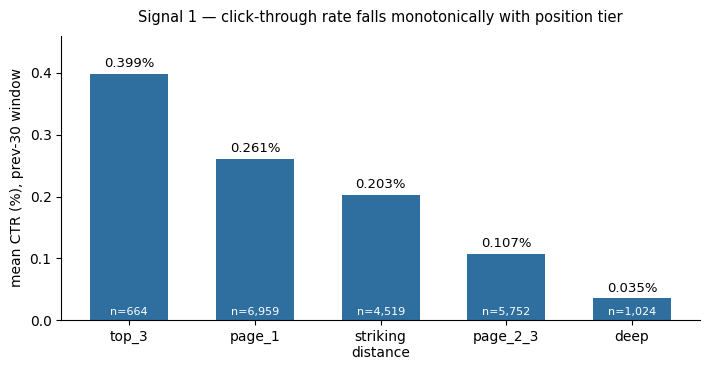

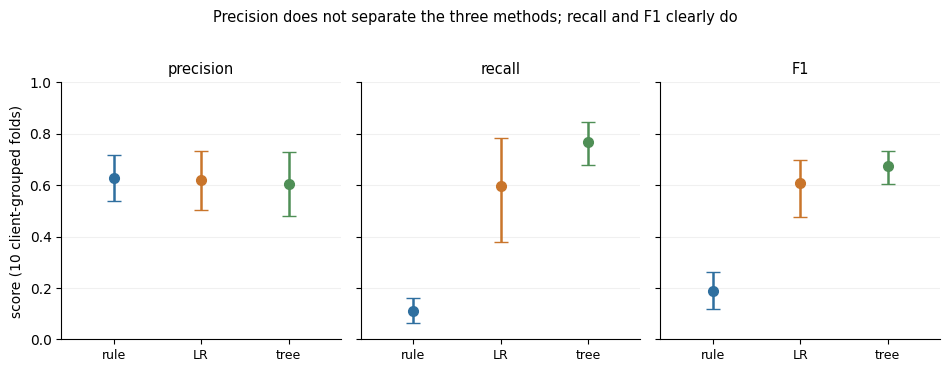

copied work/figures/w07_precision_at_k.png -> docs/assets/w07_precision_at_k.png
copied work/figures/w07_base_rate_shift.png -> docs/assets/w07_base_rate_shift.png

Assets referenced by docs/index.html that are missing: none
Credential VALUES in the served page: none
Hash-like identifiers in the served page: none

Public-safety + asset check passed. docs/ is ready to deploy.


In [30]:
import shutil

os.makedirs("docs/assets", exist_ok=True)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white", "axes.facecolor": "white"})
RULE, LR_C, TREE_C = "#2f6f9f", "#c9752b", "#4f8f56"

# ---- Figure 1: the Lane-1 signal report (numbers from w04_signal_audit.ipynb) ----
tiers = ["top_3", "page_1", "striking\ndistance", "page_2_3", "deep"]
ctr = [0.399, 0.261, 0.203, 0.107, 0.035]
n_tier = [664, 6959, 4519, 5752, 1024]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
bars = ax.bar(tiers, ctr, color=RULE, width=0.62)
for b, v, c in zip(bars, ctr, n_tier):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.011, f"{v:.3f}%", ha="center", fontsize=9.5)
    ax.text(b.get_x() + b.get_width() / 2, 0.008, f"n={c:,}", ha="center", fontsize=8, color="white")
ax.set_ylabel("mean CTR (%), prev-30 window")
ax.set_ylim(0, 0.46)
ax.set_title("Signal 1 — click-through rate falls monotonically with position tier", fontsize=10.5, pad=10)
plt.tight_layout()
plt.savefig("docs/assets/fig1_ctr_by_position.png", dpi=160, bbox_inches="tight")
plt.show()

# ---- Figure 2: precision / recall / F1 with 95% CIs (numbers from w06_validation_audit.ipynb) ----
ci_data = {
    "precision": [(0.627, 0.538, 0.719), (0.619, 0.505, 0.731), (0.603, 0.481, 0.728)],
    "recall":    [(0.111, 0.064, 0.162), (0.596, 0.380, 0.783), (0.766, 0.677, 0.845)],
    "F1":        [(0.189, 0.116, 0.260), (0.607, 0.475, 0.697), (0.675, 0.604, 0.732)],
}
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.6), sharey=True)
for ax, (metric, vals) in zip(axes, ci_data.items()):
    for i, ((m, lo, hi), c) in enumerate(zip(vals, [RULE, LR_C, TREE_C])):
        ax.errorbar(i, m, yerr=[[m - lo], [hi - m]], fmt="o", color=c, capsize=5, markersize=7, lw=1.8)
    ax.set_xticks(range(3)); ax.set_xticklabels(["rule", "LR", "tree"], fontsize=9)
    ax.set_title(metric, fontsize=10.5); ax.set_xlim(-0.6, 2.6); ax.grid(axis="y", alpha=0.18)
axes[0].set_ylabel("score (10 client-grouped folds)"); axes[0].set_ylim(0, 1.0)
fig.suptitle("Precision does not separate the three methods; recall and F1 clearly do", fontsize=10.5, y=1.02)
plt.tight_layout()
plt.savefig("docs/assets/fig2_precision_recall_f1_ci.png", dpi=160, bbox_inches="tight")
plt.show()

# ---- Figures 3 and 4: copied from where w07_action_playbook.ipynb wrote them ----
for fname in ["w07_precision_at_k.png", "w07_base_rate_shift.png"]:
    src = os.path.join("work/figures", fname)
    assert os.path.exists(src), f"Missing {src} -- re-run w07_action_playbook.ipynb first."
    shutil.copy(src, os.path.join("docs/assets", fname))
    print(f"copied {src} -> docs/assets/{fname}")

# ---- Verify the deployed page will find every asset it references ----
import re
page = open("docs/index.html").read()
missing = [s for s in re.findall(r'<img src="([^"]+)"', page) if not os.path.exists(os.path.join("docs", s))]
print(f"\nAssets referenced by docs/index.html that are missing: {missing or 'none'}")
assert not missing

# Look for real credential VALUES, not variable names -- the paper legitimately documents that
# warehouse access uses an HF_TOKEN Colab secret, and naming the variable is good practice.
secret_patterns = {
    "Hugging Face token": r"hf_[A-Za-z0-9]{16,}",
    "GitHub PAT (classic)": r"ghp_[A-Za-z0-9]{16,}",
    "GitHub PAT (fine-grained)": r"github_pat_[A-Za-z0-9_]{20,}",
    "token assigned inline": r"(?:HF_TOKEN|GH_TOKEN|API_KEY)\s*=\s*[\"\'][^\"\']{8,}",
}
hits = {name: re.findall(pat, page) for name, pat in secret_patterns.items()}
hits = {k: v for k, v in hits.items() if v}
print(f"Credential VALUES in the served page: {hits or 'none'}")
assert not hits, "A real credential appears in the deployed page."

# Client-identifying leaks: long hex strings would indicate raw pseudonymous IDs in the page
id_leaks = re.findall(r"\b[0-9a-f]{12,}\b", re.sub(r"<[^>]+>", " ", page))
print(f"Hash-like identifiers in the served page: {id_leaks or 'none'}")
assert not id_leaks, "A row-level identifier appears in the deployed page."

print("\nPublic-safety + asset check passed. docs/ is ready to deploy.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
